# KRONOS tutorial

KRONOS solves

$$\min_x f(x) \quad \text{s.t.}\quad h(x)=0,\;\; g(x)\le 0,\;\; x^L \le x \le x^U$$

by forming the full KKT system and driving its residual to zero iteratively
taking the minimum-norm least-squares solution of the KKT linear system
as the step.

Each returned point is classified as first-order KKT certified, certified with
the second-order conditions verified, or uncertified.

The method is described in Ahmed and Hasan (2026), *Computers & Chemical Engineering*, 215, 109839, [doi:10.1016/j.compchemeng.2026.109839](https://doi.org/10.1016/j.compchemeng.2026.109839).

This notebook runs from top to bottom.

## 1. Install and check

In [1]:
# KRONOS is on PyPI; it imports as `kronos`
# pip install kronos-v1
# CasADi is a core dependency; add "kronos-v1[plot]" for figures

import numpy as np
import kronos
from kronos import Problem, Options, solve, load_problem, problem_names, find

print("kronos          :", kronos.__version__)
print("built-in problems:", len(problem_names()))

kronos          : 0.4.8
built-in problems: 244


## 2. Solve a built-in problem

244 problems are included, drawn from the Hock-Schittkowski collection, CUTEst,
and standard global-optimisation test functions. They range from 2 to 1000
variables and each carries its known optimum.

In [2]:
names = problem_names()
print(f"{len(names)} problems, from n={min(load_problem(n).n for n in names[:20])} upwards")
print()
print("  first 20 :", names[:20])
print("  hs family:", find("hs")[:12], "...")

244 problems, from n=2 upwards

  first 20 : ('a01_beale', 'a02_bohachevsky1', 'a03_bohachevsky2', 'a04_bohachevsky3', 'a05_branin_rcos', 'a06_colville', 'a07_dixon_price', 'a08_hump', 'a09_matyas', 'a10_perm', 'a11_powell_singular', 'a13_sphere', 'a14_sum_squares', 'a15_trid', 'a16_zakharov', 'a17_branin_rcos2', 'a18_ackley1', 'a19_ackley2', 'a20_camel3', 'a21_booth')
  hs family: ['genhs28', 'hs001', 'hs003', 'hs004', 'hs005', 'hs006', 'hs007', 'hs008', 'hs009', 'hs010', 'hs012', 'hs014'] ...


In [3]:
p = load_problem("hs053")
print(p, " known optimum f* =", p.fstar)

r = solve(p, multi_start=True, ms_num_starts=25, ms_seed=42)
print(r.summary())

Problem('hs053', n=15, m=13, slack_rows=10)  known optimum f* = 4.093


  KRONOS  |  hs053   n=15  m=13
  converged   : 25/25  (100.0%)
  reached f*  : 25/25  (100.0%)
  time        : 0.686 s   (0.027 s/run)
  ---- best run ----
  status      : converged (KKT certified)
  objective   : 4.093023256      f* = 4.093
  x*          : theta1     = -0.7674418605
                theta2     = 0.2558139535
                theta3     = 0.6279069767
                theta4     = -0.1162790698
                theta5     = 0.2558139535
  iterations  : 3


The same quantities are available programmatically. `solve` also accepts an
`Options` object, and the derivative backend can be inspected or chosen
explicitly.

Note the distinction between *converged* and *reformulated stationary*: because
inequalities are carried as squared slacks, a run can drive the residual to
zero and still end with a wrong-signed multiplier. Such a point is stationary
for the reformulated system but is not a KKT point of the original problem, and
is not counted as converged.

In [4]:
from kronos import Options, get_backend

opts = Options(multi_start=True, ms_num_starts=25, ms_seed=42)
backend = get_backend(p, opts.backend, switch_n=opts.backend_switch_n)

print("backend used     :", backend.name, f"(n={p.n}, switches to casadi at {opts.backend_switch_n})")
print("tolerances       :", f"tol_r={opts.tol_r:g}, tol_h={opts.tol_h:g}, maxIter={opts.maxIter}")
print("warm-up          :", f"adam={opts.use_adam_warmup}, mode={opts.adam_mode}")
print()
print("best objective   :", r.fval)
print("best point       :", np.round(r.theta[[i for i in r.info["user_vars"]]], 6))
print("converged runs   :", r.n_conv, "/", len(r.runs), "  (KKT certified)")
print("reformulated only:", r.n_reformulated_stationary - r.n_conv,
      "  (residual met, multiplier sign wrong)")
print("reached f*       :", r.global_hits(p.fstar), "/", len(r.runs))
print("per-run objectives:", np.round(r.all_fvals[:6], 6), "...")

backend used     : sympy (n=15, switches to casadi at 20)
tolerances       : tol_r=1e-05, tol_h=1e-05, maxIter=2000
warm-up          : adam=True, mode=C

best objective   : 4.093023255813954
best point       : [-0.767442  0.255814  0.627907 -0.116279  0.255814]
converged runs   : 25 / 25   (KKT certified)
reformulated only: 0   (residual met, multiplier sign wrong)
reached f*       : 25 / 25
per-run objectives: [4.093023 4.093023 4.093023 4.093023 4.093023 4.093023] ...


## 3. Convergence and certification

A run may reduce the KKT residual to zero and still end with an inequality
multiplier of the wrong sign. Such a point is stationary for the reformulated
system but is not a KKT point of the original problem, so `kkt_certified`
rather than the residual test is the flag that matters.

`n_conv` counts only certified runs. The looser count, without the
multiplier-sign requirement, is `n_reformulated_stationary`:

In [5]:
p = load_problem("hs071")
r = solve(p, multi_start=True, ms_num_starts=25, ms_seed=42)

print("converged (certified)   :", r.n_conv, "/", len(r.runs))
print("reformulated stationary :", r.n_reformulated_stationary, "/", len(r.runs))
print("of which uncertified    :", r.n_reformulated_stationary - r.n_conv)

converged (certified)   : 17 / 25
reformulated stationary : 25 / 25
of which uncertified    : 8


## 4. Strict local minima

A certified KKT point is not necessarily a minimum. It may be a maximum or a
saddle point. The second-order sufficient condition separates them, and is
checked automatically.

To count how many runs are proven minima, read `n_local`:

In [6]:
for name in ("hs053", "hs071", "a01_beale"):
    q = load_problem(name)
    res = solve(q, multi_start=True, ms_num_starts=25, ms_seed=42)
    print(f"{name:<12} converged {res.n_conv:>2}/25   strict local minima {res.n_local:>2}/25"
          f"   (failed SOSC {res.n_stationary}, untested {res.n_sosc_unmeasured})")

hs053        converged 25/25   strict local minima 25/25   (failed SOSC 0, untested 0)


hs071        converged 17/25   strict local minima 10/25   (failed SOSC 4, untested 3)


a01_beale    converged 23/25   strict local minima  4/25   (failed SOSC 19, untested 0)


On `a01_beale` most runs reach certified KKT points, yet few of them are
minima. Reading `n_conv` alone would overstate the result.

The gap between `n_conv` and `n_local` splits two ways, and they always sum:

| attribute | meaning |
|---|---|
| `n_local` | certified **and** second-order test passed |
| `n_stationary` | certified, test ran, point is not a minimum |
| `n_sosc_unmeasured` | certified, test not performed |

Runs solved by the Fischer-Burmeister formulation land in the third category,
because that path does not form a reduced Hessian. Not measured is not the
same as failed.

Per run, the second-order test reports `sosc_pass`, `sosc_measured` and
`lam_min_red`. `lam_min_red` is the smallest eigenvalue of the Hessian of the
Lagrangian restricted to the null space of the active constraint Jacobian; a
positive value means a strict local minimum.

`check_sosc=False` skips the test, and `sosc_tol` sets the eigenvalue threshold.

## 5. Defining a problem

Supply the objective, the constraints and the bounds. Slack variables for the
inequalities and bounds are introduced internally and need not be provided.

In [7]:
p = Problem.build(
    "my_problem", ["x1", "x2", "x3", "x4"],
    objective    = "x1*x4*(x1 + x2 + x3) + x3",
    equalities   = ["x1**2 + x2**2 + x3**2 + x4**2 - 40"],   # each means == 0
    inequalities = ["25 - x1*x2*x3*x4"],                     # each means <= 0
    lb = [1, 1, 1, 1],
    ub = [5, 5, 5, 5],
    x0 = [1, 5, 5, 1],
    fstar = 17.0140173,                                      # optional
)

r = solve(p, multi_start=True, ms_num_starts=25, ms_seed=42)
print(f"objective : {r.fval:.8f}   (known optimum {p.fstar})")
print(f"x*        : {np.round(r.theta[:4], 6)}")
print(f"certified : {r.n_kkt}/{len(r.runs)} runs")

objective : 17.01401436   (known optimum 17.0140173)
x*        : [1.       4.743    3.82115  1.379408]
certified : 21/25 runs


Further options:

- `inequality_sense=">="` for `>=` constraints (or a list, one entry per row)
- `variables=8` instead of a name list, giving `x1..x8`
- SymPy expressions instead of strings
- `p.save("mine.json")` / `Problem.load("mine.json")` to store problems

In [8]:
import sympy as sp

x, y = sp.symbols("x y", real=True)
rosen = Problem.build("rosen", ["x", "y"],
                      objective=100*(y - x**2)**2 + (1 - x)**2, x0=[-1.2, 1.0])
print("Rosenbrock :", solve(rosen, maxIter=800).fval, np.round(solve(rosen, maxIter=800).theta, 6))

n = 8
quad = Problem.build("quad", n,
                     objective=" + ".join(f"{i+1}*(x{i+1} - {i})**2" for i in range(n)),
                     x0=np.zeros(n))
print("generated n=8:", solve(quad, maxIter=500).fval)

Rosenbrock : 6.64640450890118e-16 [1. 1.]
generated n=8: 1.1339875512552045e-30


## 6. Rank-deficient constraints

This is the case the method is built for. Consider

$$
\begin{aligned}
\min_{x,y}\quad & (x-1)^2 + (y-2)^2 \\
\textrm{s.t.}\quad & x + y = 3 \\
& 2x + 2y = 6
\end{aligned}
$$

The second constraint is twice the first and carries no new information, so the
constraint Jacobian

$$J_h = \begin{bmatrix} 1 & 1 \\ 2 & 2 \end{bmatrix}$$

has $\operatorname{rank}(J_h) = 1 < 2$. The solution is clearly $(1, 2)$, since
that point already satisfies $x + y = 3$.

In [9]:
p = Problem.build("redundant", ["x", "y"],
                  objective   = "(x - 1)**2 + (y - 2)**2",
                  equalities  = ["x + y - 3",
                                 "2*x + 2*y - 6"],     # twice the first
                  x0 = [0.0, 0.0])

from kronos import get_backend
Jh = get_backend(p, "sympy").Jh(np.array([0.0, 0.0]))
print("constraint Jacobian:\n", Jh)
print("rank =", np.linalg.matrix_rank(Jh), "of", min(Jh.shape))

constraint Jacobian:
 [[1. 1.]
 [2. 2.]]
rank = 1 of 2


The redundancy propagates into the full KKT matrix, which becomes singular. A
Newton step formed by inverting it fails outright:

In [10]:
from kronos.core import _Assembler
from kronos import Options, lsqminnorm

b = get_backend(p, "sympy")
A = _Assembler(b, p.n, p.m, Options().use_dummy_variable)
z = np.concatenate([[1.0], np.array([1.0, 2.0])])
R, J, _, _, _ = A(z, np.zeros(1 + p.m))

print("KKT matrix    :", J.shape, " rank", np.linalg.matrix_rank(J), "of", J.shape[0])
print("condition no. : %.3e" % np.linalg.cond(J))
print("singular values:", np.array2string(np.linalg.svd(J, compute_uv=False), precision=3))
print()
try:
    np.linalg.solve(J, R)
except np.linalg.LinAlgError as e:
    print("np.linalg.solve(J, R) ->", type(e).__name__ + ":", e)
print("minimum-norm step     ->", np.round(lsqminnorm(J, R), 12))

KKT matrix    : (6, 6)  rank 5 of 6
condition no. : 1.311e+32
singular values: [4.317e+00 2.414e+00 2.317e+00 2.000e+00 4.142e-01 3.293e-32]

np.linalg.solve(J, R) -> LinAlgError: Singular matrix
minimum-norm step     -> [0. 0. 0. 0. 0. 0.]


The minimum-norm least-squares step is defined regardless, so the solve
proceeds normally:

In [11]:
r = solve(p, multi_start=True, ms_num_starts=10, ms_seed=42)
print(r.summary())

  KRONOS  |  redundant   n=2  m=2
  converged   : 10/10  (100.0%)
  time        : 0.278 s   (0.028 s/run)
  ---- best run ----
  status      : converged (KKT certified)
  objective   : 1.232595164e-32
  x*          : x          = 1
                y          = 2
  iterations  : 2


Every start converges to $(1, 2)$ with an objective at machine precision.

Redundant constraints of this kind are not artificial: they arise from
conservation relations that are not independent, from over-specified models,
and from constraints that become linearly dependent only at the solution.

## 7. Searching the built-in problems

In [12]:
print("by name       :", find("hs"))
print("small + constrained:", find(max_n=6, constrained=True))
print("unconstrained :", find(constrained=False)[:8], "...")

for nm in find(max_n=4):
    q = load_problem(nm)
    print(f"  {nm:<12} n={q.n:<3} m={q.m:<3} f*={q.fstar}")

by name       : ['genhs28', 'hs001', 'hs003', 'hs004', 'hs005', 'hs006', 'hs007', 'hs008', 'hs009', 'hs010', 'hs012', 'hs014', 'hs015', 'hs017', 'hs018', 'hs019', 'hs020', 'hs023', 'hs026', 'hs027', 'hs028', 'hs029', 'hs030', 'hs031', 'hs032', 'hs033', 'hs034', 'hs038', 'hs040', 'hs042', 'hs043', 'hs046', 'hs047', 'hs048', 'hs049', 'hs050', 'hs051', 'hs052', 'hs053', 'hs054', 'hs055', 'hs056', 'hs060', 'hs061', 'hs063', 'hs065', 'hs066', 'hs071', 'hs077', 'hs078', 'hs079', 'hs080', 'hs081', 'hs100nlp', 'hs107', 'hs108', 'hs110', 'hs113', 'hs3mod']


small + constrained: ['aircrfta', 'alsotame', 'b11', 'b13', 'b16', 'b24', 'booth', 'box2', 'bqp1var', 'bt1', 'bt10', 'bt11', 'bt12', 'bt13', 'bt2', 'bt3', 'bt5', 'bt6', 'bt7', 'bt8', 'byrdsphr', 'camel6', 'cluster', 'extrasim', 'gottfr', 'hatfldf', 'heart6', 'himmelba', 'himmelbc', 'himmelp1', 'hs001', 'hs003', 'hs004', 'hs005', 'hs006', 'hs007', 'hs008', 'hs009', 'hs010', 'hs012', 'hs014', 'hs015', 'hs026', 'hs027', 'hs028', 'hs029', 'hs040', 'hs046', 'hs047', 'hs048', 'hs049', 'hs050', 'hs051', 'hs052', 'hs061', 'hs063', 'hs077', 'hs078', 'hs079', 'hs3mod', 'hypcir', 'maratos', 'mwright', 'powellsq', 'pspdoc', 'sim2bqp', 'simbqp', 'supersim', 'tame', 'try_b', 'yfit', 'zangwil3']
unconstrained : ['a01_beale', 'a02_bohachevsky1', 'a03_bohachevsky2', 'a04_bohachevsky3', 'a05_branin_rcos', 'a06_colville', 'a07_dixon_price', 'a08_hump'] ...
  a01_beale    n=2   m=0   f*=0.0383
  a02_bohachevsky1 n=2   m=0   f*=0.0
  a03_bohachevsky2 n=2   m=0   f*=0.0
  a04_bohachevsky3 n=2   m=0   f*=0.0

## 8. Multistart

Nonconvex problems have many KKT points. Multistart scatters starting points
across the feasible region and records what each one reaches, which indicates
how many find the optimum.

converged 25/25, certified 25/25, reached f* 25/25


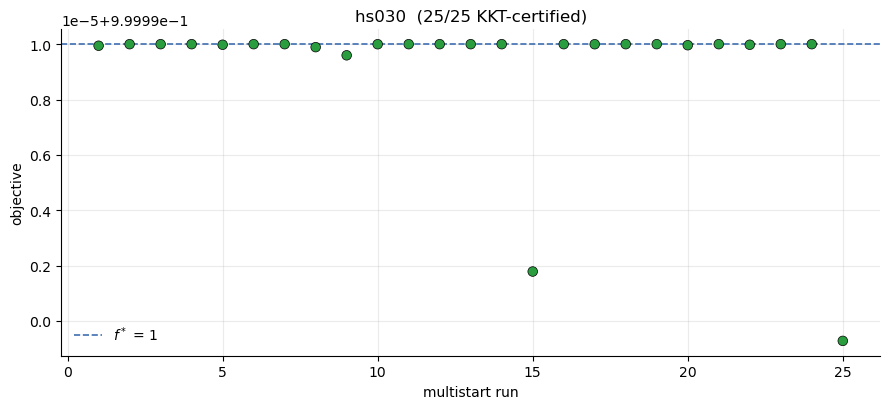

In [13]:
%matplotlib inline
from kronos.plotting import plot_runs

p = load_problem("hs030")
r = solve(p, multi_start=True, ms_num_starts=25, ms_seed=42)
print(f"converged {r.n_conv}/25, certified {r.n_kkt}/25, reached f* {r.global_hits(p.fstar)}/25")
plot_runs(r, fstar=p.fstar)

Green marks converged (KKT-certified) runs, amber runs that met the residual
test without certification, and grey failed runs. The dashed line is the known
optimum.

## 9. Options

Options may be passed as keyword arguments to `solve` or collected in an
`Options` object for reuse. The convergence tolerance is the most commonly
adjusted setting.

`adam_mode` controls how the warm-up and pre-feasibility stages are distributed
over the starting points: `"A"` warms every point but pre-solves only the
first, `"B"` warms only the first, and `"C"` (the default) runs the whole
pipeline independently for each point. See the README for a comparison.

In [14]:
p = load_problem("hs048")

loose = solve(p, tol_r=1e-3)
tight = solve(p, tol_r=1e-10, maxIter=5000)

print(f"tol_r=1e-3   final |residual| = {loose.runs[loose.best_run].max_r:.3e}   "
      f"iters={loose.runs[loose.best_run].iterations}")
print(f"tol_r=1e-10  final |residual| = {tight.runs[tight.best_run].max_r:.3e}   "
      f"iters={tight.runs[tight.best_run].iterations}")

tol_r=1e-3   final |residual| = 2.371e-12   iters=1
tol_r=1e-10  final |residual| = 2.371e-12   iters=1


`tol_r` is the KKT residual tolerance and `tol_h` the constraint-violation tolerance; both default to `1e-5`. Set them together for a uniformly tighter solve:

```python
r = solve(p, tol_r=1e-8, tol_h=1e-8, maxIter=5000)
```

You never have to read the source to find a setting — every option is self-documenting, grouped by what it affects:

In [15]:
from kronos import Options
print(Options.describe("Convergence"))

Convergence
-----------
  tol_r                     = 1e-05       converged when max|KKT residual| < tol_r
  tol_h                     = 1e-05       converged when max|constraint violation| < tol_h
  maxIter                   = 2000        maximum Newton iterations per run


In [16]:
# every group: Convergence, Multistart, Line search and robustness,
# Warm-up and pre-feasibility, Certification, Numerics, Backend,
# Output, Advanced multiplier handling
print(Options.describe("Certification"))

Certification
-------------
  check_kkt_sign            = True        check inequality multiplier signs at convergence
  enforce_kkt_sign          = True        reject and retry runs with wrong-signed multipliers
  max_kkt_kicks             = 5           retries allowed before giving up on the sign check
  dual_feas_tol             = 1e-06       tolerance on multiplier sign (dual feasibility)
  check_sosc                = True        test the second-order condition (verified minimum)
  sosc_tol                  = 1e-06       reduced-Hessian eigenvalue above which SOSC passes
  fb_enable                 = True        Fischer-Burmeister fallback for wrong-signed runs
  fb_eps                    = 1e-06       smoothing parameter in the Fischer-Burmeister function


`Options.describe()` with no argument prints all 58 options. The same listing is available from the shell with `kronos options`.

## 10. Backends

With `backend="auto"` the solver uses SymPy below 20 variables and CasADi at or
above that threshold. JAX is available as a third option. The backends produce
mathematically equivalent derivatives; floating-point evaluation differs
between them, so a run may follow a slightly different trajectory.

Compiling the derivatives is a one-off cost, so a backend can be reused across
repeated solves of the same problem.

In [17]:
import time
from kronos import get_backend, available_backends
print("available:", available_backends())

p = load_problem("hs110")
b = get_backend(p, "auto")
t0 = time.time()
for seed in (1, 2, 3):
    solve(p, multi_start=True, ms_num_starts=5, ms_seed=seed, backend=b)
print(f"3 solves reusing one compiled backend: {time.time()-t0:.2f} s")

available: ['sympy', 'casadi']


3 solves reusing one compiled backend: 1.15 s


## 11. A larger problem

The built-in set extends to 600 variables and beyond. CasADi is used
automatically at this size.

In [18]:
p = load_problem("gridneth")       # n = 62, 37 constraints
t0 = time.time()
r = solve(p, multi_start=True, ms_num_starts=10, ms_seed=42)
print(f"n={p.n}, m={p.m}: converged {r.n_conv}/10, certified {r.n_kkt}/10, "
      f"f={r.fval:.6f}, {time.time()-t0:.1f}s")

n=62, m=37: converged 10/10, certified 10/10, f=39.626269, 5.8s


## 12. Further reading

- `README.md` documents every option.
- `examples/` contains short runnable scripts.
- `kronos.lsqminnorm` exposes the minimum-norm least-squares kernel directly:

```python
from kronos import lsqminnorm
x = lsqminnorm(A, b)     # min ||x|| over argmin ||Ax - b||
```

The method is described in Ahmed and Hasan (2026), *Computers & Chemical Engineering*, 215, 109839, [doi:10.1016/j.compchemeng.2026.109839](https://doi.org/10.1016/j.compchemeng.2026.109839).